# 01. Exploratory Data Analysis & Text Cleaning

**Goal:** Understand the IMDB dataset, deal with HTML artifacts, and make a critical decision regarding stopword removal.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../../../shared')
from text_utils import clean_html_text

## 1. Load Data

In [2]:
df = pd.read_csv('../data/raw/dataset.csv')
print(df.head())
print(df.info())

                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    50000 non-null  str  
 1   label   50000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 63.2 MB
None


## 2. Target Distribution

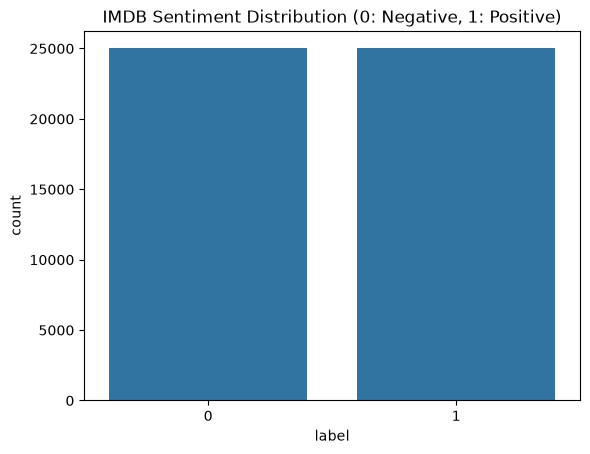

In [3]:
sns.countplot(x='label', data=df)
plt.title('IMDB Sentiment Distribution (0: Negative, 1: Positive)')
plt.show()

## 3. Look at HTML Artifacts

In [4]:
# Let's see an example of a dirty review
print(df['text'].iloc[0][:500])

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent


> **📌 Decision Note — Why Text Cleaning Strategy?**
>
> **Chosen approach:** Regex HTML Removal + Basic Cleaning, BUT NO Stopword Removal
>
> **Why this works:** HTML tags like `<br />` add no semantic value. However, keeping stopwords ensures we don't lose crucial negations (like 'not', 'very', 'too').
>
> **Alternatives we could have used:**
> | Option | Pros | Cons |
> |--------|------|------|
> | Standard Cleaning (Remove Stopwords) | Reduces matrix size massively | Destroys negations! 'This is not a good movie' becomes 'good movie'. |
> | Advanced Lemmatization | Standardizes words | For 50,000 reviews, lemmatizing is very slow and the sentiment is usually captured fine by raw words. |
>
> **Why we chose this over alternatives:** In sentiment analysis, negations and modifiers are extremely important. Standard stopword removal is detrimental.

## 4. Apply HTML Cleaning

In [5]:
df['cleaned_text'] = df['text'].apply(clean_html_text)
df[['label', 'text', 'cleaned_text']].head()

,label,text,cleaned_text
0,0,I rented I AM CURIOUS-YELLOW from my video sto...,i rented i am curiousyellow from my video stor...
1,0,"""I Am Curious: Yellow"" is a risible and preten...",i am curious yellow is a risible and pretentio...
2,0,If only to avoid making this type of film in t...,if only to avoid making this type of film in t...
3,0,This film was probably inspired by Godard's Ma...,this film was probably inspired by godards mas...
4,0,"Oh, brother...after hearing about this ridicul...",oh brotherafter hearing about this ridiculous ...


In [6]:
df.to_csv('../data/processed/cleaned_imdb.csv', index=False)
print('Saved cleaned dataset.')

Saved cleaned dataset.
